
Model                 Best Val F1
BiLSTM                     0.5589
GRU                        0.5412
BERT-base                  0.9091
BERTweet                   0.6317
RoBERTA                    0.6723


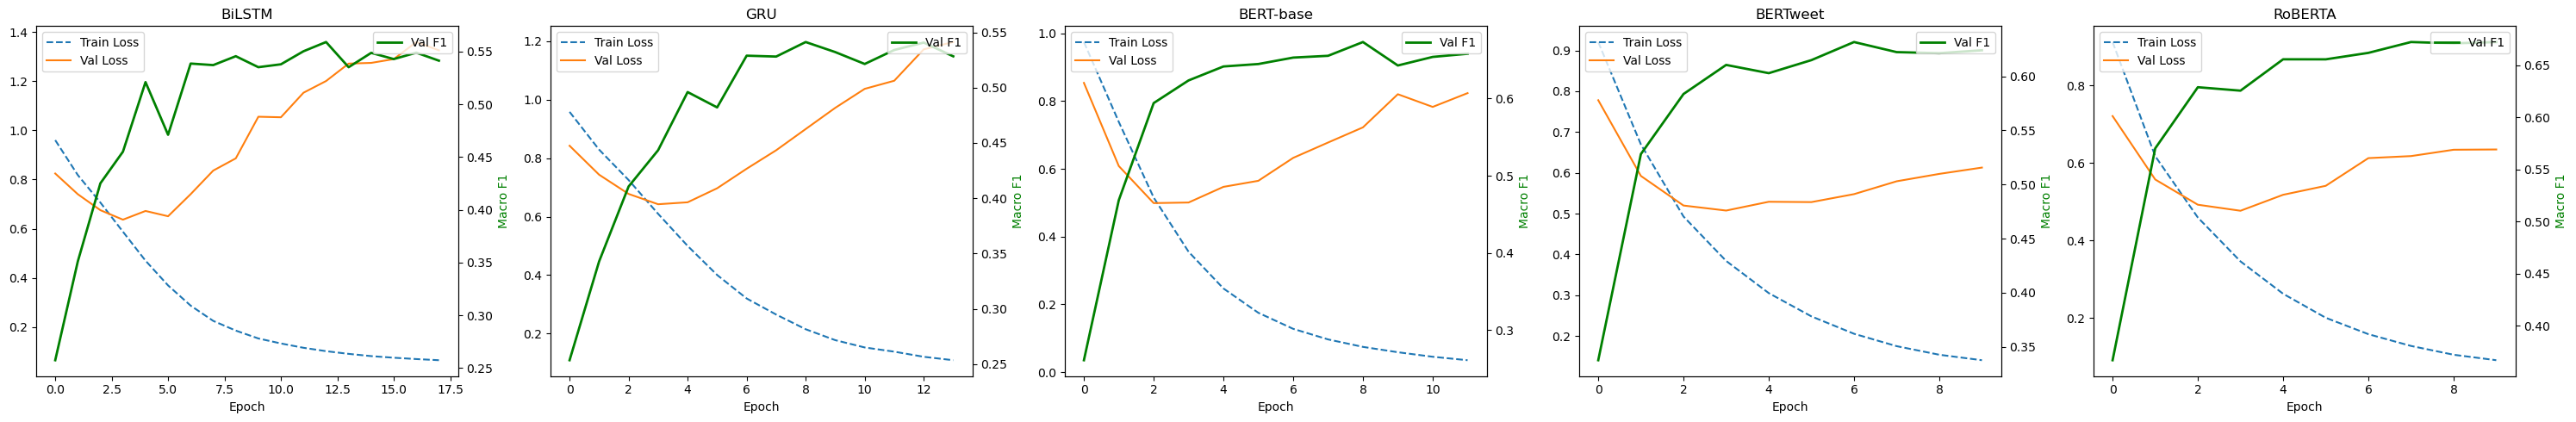

In [2]:
# --- LOAD ALL RESULTS ---
import pickle, pandas as pd, matplotlib.pyplot as plt, numpy as np

results = {}
for name, fname in [
    ('BiLSTM',    'history_bilstm.pkl'),
    ('GRU',       'history_gru.pkl'),
    ('BERT-base', 'history_bert_base.pkl'),
	('BERTweet',  'history_bertweet.pkl'),
	('RoBERTA',   'history_roberta_base.pkl')
]:
    try:
        with open(f'./checkpoints/{fname}', 'rb') as f:
            results[name] = pickle.load(f)
    except FileNotFoundError:
        print(f"  ⚠ {fname} not found yet — train that model first")

# --- SUMMARY TABLE ---
print(f"\n{'Model':<20} {'Best Val F1':>12}")
print("=" * 35)
for name, r in results.items():
    print(f"{name:<20} {r['best_f1']:>12.4f}")

# --- TRAINING CURVES (side by side) ---
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
if len(results) == 1: axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    h = r['history']
    ax.plot(h['train_loss'], '--', label='Train Loss')
    ax.plot(h['val_loss'],        label='Val Loss')
    ax2 = ax.twinx()
    ax2.plot(h['val_f1'], color='green', linewidth=2, label='Val F1')
    ax2.set_ylabel('Macro F1', color='green')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('./training_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()